In [20]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
from tensorflow.keras import layers

TensorFlow version: 2.5.0


In [21]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from datetime import datetime

In [22]:
from pathlib import Path
current_dir = os.path.join(Path().resolve())
sys.path.append(str(current_dir) + '/../')

In [23]:
from ReservoirRun import Reservoir
from evolver import DaccadBioneatMut, DaccadBioneatMut_5
from qdpy.containers import *
from individual import *

## Loading a dataset

In [24]:
myarray_np = np.loadtxt('../data/dataset_myarray_1_plus_eigenvalue.csv', delimiter=',')
mc_np = np.loadtxt('../data/dataset_mc_1.csv', delimiter=',')

In [25]:
myarray_np.shape

(1638, 156)

In [26]:
# save as a npz file
np.save('../data/myarray_eigen', myarray_np)
np.save('../data/mc_eigen', mc_np)

## Split into train data and test data as dataset

In [27]:
myarray_fullPath = os.path.abspath('./data/myarray_eigen.npy')
myarray_path = tf.keras.utils.get_file('myarray_eigen.npy', 'file://'+myarray_fullPath)
myarray_data = np.load(myarray_path)
#x_train, x_test = train_test_split(myarray_data, test_size=0.2)


mc_fullPath = os.path.abspath('./data/mc_eigen.npy')
mc_path = tf.keras.utils.get_file('mc_eigen.npy', 'file://'+mc_fullPath)
mc_data = np.load(mc_path)
#y_train, y_test = train_test_split(mc_data, test_size=0.2)
x_train, x_test, y_train, y_test = train_test_split(myarray_data, mc_data, test_size=0.2)

print(len(x_train), 'train examples')
print(len(x_test), 'test examples')
print(len(y_train), 'train examples')
print(len(y_test), 'test examples')

1310 train examples
328 test examples
1310 train examples
328 test examples


In [28]:
x_train

array([[  51.64820693,   41.33525115,   75.76483684, ...,    0.        ,
           0.        ,   28.61020137],
       [   5.1       ,    5.1       ,  263.7967542 , ...,    0.        ,
           0.        ,   33.9337676 ],
       [  26.64400315,  837.278468  , 1000.        , ...,    0.        ,
           0.        ,   15.36181323],
       ...,
       [  14.26695983,    5.34502024,   43.4505546 , ...,    0.        ,
           0.        ,   43.23210117],
       [1000.        ,    5.1       , 1000.        , ...,    0.        ,
           0.        ,   28.96764956],
       [   5.1       ,    5.1       ,   54.53746463, ...,    0.        ,
           0.        ,   11.31340611]])

In [29]:
myarray_data.shape

(1638, 156)

In [30]:
x_train.shape

(1310, 156)

In [31]:
# Add a channels dimension
#x_train = x_train[..., tf.newaxis]
#x_test = x_test[..., tf.newaxis]

In [32]:
x_train.shape

(1310, 156)

In [33]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

## Set my model

In [34]:
def build_model():
    model = tf.keras.Sequential([
        layers.Dense(10, activation='relu', input_shape=[156]),
        layers.Dense(5),
        layers.Dense(1)
    ])

    #optimizer = tf.keras.optimizers.RMSprop(0.001)
    optimizer = tf.keras.optimizers.Adam()

    model.compile(loss='mse',
                optimizer=optimizer,
                metrics=['mae', 'mse'])
    return model

In [35]:
model = build_model()

In [36]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 10)                1570      
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 55        
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 6         
Total params: 1,631
Trainable params: 1,631
Non-trainable params: 0
_________________________________________________________________


In [37]:
example_batch = x_train[:10]
example_result = model.predict(example_batch)
example_result

array([[-39.154564  ],
       [  4.8188667 ],
       [-37.518524  ],
       [  1.2987933 ],
       [-12.389103  ],
       [-53.92517   ],
       [-64.511566  ],
       [ 47.15271   ],
       [ 26.408587  ],
       [  0.31411266]], dtype=float32)

In [38]:
# エポックが終わるごとにドットを一つ出力することで進捗を表示
class PrintDot(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0: print('')
        print('.', end='')

EPOCHS = 100

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS, validation_split = 0.2, verbose=0,
    callbacks=[PrintDot()]
)


....................................................................................................

In [39]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
95,119.194542,8.285424,119.194542,299.766907,12.601119,299.766907,95
96,119.149834,8.254820,119.149834,293.466888,12.560072,293.466888,96
97,116.710602,8.171350,116.710602,304.725403,12.643304,304.725403,97
98,120.199287,8.280639,120.199287,301.348083,12.647202,301.348083,98
99,117.583366,8.223618,117.583366,297.191315,12.567101,297.191315,99


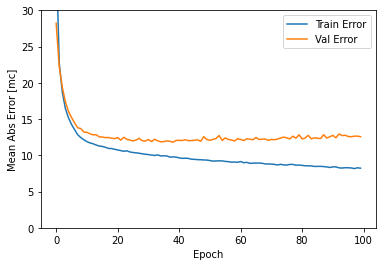

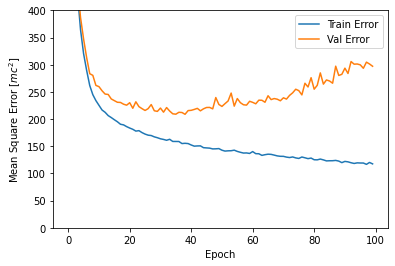

In [40]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [mc]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
    plt.ylim([0,30])
    plt.legend()

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error [$mc^2$]')
    plt.plot(hist['epoch'], hist['mse'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mse'], label = 'Val Error')
    plt.ylim([0,400])
    plt.legend()
    plt.show()


plot_history(history)

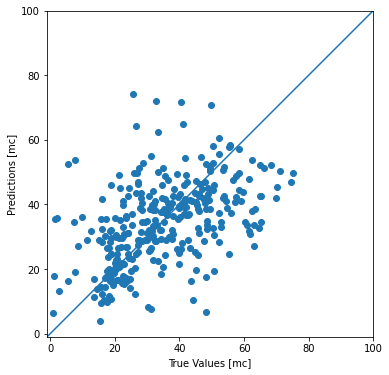

In [41]:
test_predictions = model.predict(x_test).flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [mc]')
plt.ylabel('Predictions [mc]')
plt.axis('equal')
plt.axis('square')
plt.xlim([-1,100])
plt.ylim([-1,100])
_ = plt.plot([-100, 100], [-100, 100])

In [42]:
np.corrcoef(y_test, test_predictions)

array([[1.        , 0.40981723],
       [0.40981723, 1.        ]])